# Bonus Task — Error Analysis on the Winning Model (LDA)

This notebook performs a detailed error analysis on the LDA model identified as the winning algorithm in Task 3, using the stable feature subset chosen in Task 4. The objective is to characterise which patients the model misclassifies and why — producing actionable insight for clinical deployment.

## Approach

**Step B1 — Train/validation split.** A single 70/30 stratified split is used (rather than cross-validation). Following the bonus task description: *"split the dataset into a training and a validation set, train the model on the training data, and evaluate its performance on the validation set."* The validation set is genuinely held out from training.

**Step B2 — Predictions and error categorisation.** The trained model predicts on the validation set. Each validation patient is assigned to one of four categories: true positive (TP), true negative (TN), false positive (FP), or false negative (FN).

**Step B3 — Demographic and clinical comparison.** We compare the distributions of clinical features (age, sex, all 5 stable features) across the four error categories, using boxplots/bar charts and appropriate statistical tests (Mann-Whitney U for continuous, Fisher's exact for binary).

**Step B4 — SHAP-based error analysis.** SHAP values are computed for each validation patient. We compare SHAP value distributions across the error categories to identify which features drive correct vs incorrect predictions, and whether errors are associated with atypical SHAP patterns.

**Step B5 — Subgroup error rates.** Error rates stratified by sex, age band, and key clinical features identify patient subgroups at higher risk of misclassification.

**Step B6 — Clinician-oriented report.** A summary of how the model decides, what drives errors, which subgroups are at risk, and what limitations apply for clinical deployment.

**Important caveat:** With a 30% validation split on n=242, the validation set contains ~73 patients. At ~85% accuracy this leaves ~10-12 misclassifications, which is a small base for subgroup analysis. Any subgroup-specific finding should be interpreted as a hypothesis-generating signal rather than a definitive pattern.

In [1]:
# ── Setup ──────
import sys, os, pickle, time
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy import stats

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection       import train_test_split
from sklearn.pipeline              import Pipeline

from src import build_preprocessor, FeatureSubsetSelector, compute_metrics

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PALETTE = {0: '#4C72B0', 1: '#DD8452'}
ERROR_COLORS = {'TP': '#2E7D32', 'TN': '#1565C0',
                'FP': '#E65100', 'FN': '#C62828'}
os.makedirs('../figures/bonus', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Data and Final Model Configuration

In [2]:
# ── Load data and previous task results ───────
df = pd.read_csv('../data/students_dataset.csv')
X  = df.drop('num', axis=1)
y  = df['num'].values

# Load stable features (from Task 4) and HPs (from Task 5)
with open('../results/task4_selected_features.pkl', 'rb') as f:
    fs_info = pickle.load(f)
stable_features = fs_info['stable_features']

with open('../models/final_model.pkl', 'rb') as f:
    model_info = pickle.load(f)
best_hp = model_info['best_hp']

print(f'Dataset: {X.shape[0]} samples × {X.shape[1]} features')
print(f'Stable features ({len(stable_features)}): {stable_features}')
print(f'LDA hyperparameters: {best_hp}')

Dataset: 242 samples × 13 features
Stable features (5): ['ca', 'thal', 'sex', 'cp', 'exang']
LDA hyperparameters: {'solver': 'eigen', 'shrinkage': 0.005997182955817526}


## 2. Step B1 — Train/Validation Split and Model Training

We use a **70/30 stratified split**, preserving the class ratio in both partitions. The same hyperparameters chosen in Task 5 are applied — we are not re-tuning here, since the task is about understanding errors, not about further optimisation.

In [3]:
# ── Stratified 70/30 split ──────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

print(f'Training set:   {X_train.shape[0]} patients '
      f'({(y_train == 1).sum()} disease, {(y_train == 0).sum()} healthy)')
print(f'Validation set: {X_val.shape[0]} patients '
      f'({(y_val == 1).sum()} disease, {(y_val == 0).sum()} healthy)')

Training set:   169 patients (78 disease, 91 healthy)
Validation set: 73 patients (33 disease, 40 healthy)


In [4]:
# ── Build and fit the model ─────
model = Pipeline([
    ('subset',       FeatureSubsetSelector(features=stable_features)),
    ('preprocessor', build_preprocessor(feature_subset=stable_features)),
    ('lda',          LinearDiscriminantAnalysis(**best_hp)),
])
model.fit(X_train, y_train)
print('Model trained on the 70% training partition.')

Model trained on the 70% training partition.


## 3. Step B2 — Predictions and Error Categorisation

In [5]:
# ── Predict on the validation set ──────
y_pred  = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

# Performance overview
metrics = compute_metrics(y_val, y_pred, y_proba)
print('Validation-set performance:')
for m, v in metrics.items():
    print(f'  {m:<14s} {v:.3f}')

Validation-set performance:
  mcc            0.723
  balanced_acc   0.859
  f1             0.844
  recall         0.818
  precision      0.871
  specificity    0.900
  auc            0.919
  pr_auc         0.914


In [6]:
# ── Categorise each validation patient ───────
def categorise(y_true, y_pred):
    if   y_true == 1 and y_pred == 1: return 'TP'
    elif y_true == 0 and y_pred == 0: return 'TN'
    elif y_true == 0 and y_pred == 1: return 'FP'
    elif y_true == 1 and y_pred == 0: return 'FN'

val_df = X_val.copy()
val_df['y_true']   = y_val
val_df['y_pred']   = y_pred
val_df['y_proba']  = y_proba
val_df['category'] = [categorise(t, p) for t, p in zip(y_val, y_pred)]

print('Validation-set categorisation:')
for cat in ['TP', 'TN', 'FP', 'FN']:
    n = (val_df['category'] == cat).sum()
    print(f'  {cat}: {n:2d} patients')
n_correct = (val_df['category'].isin(['TP', 'TN'])).sum()
n_errors  = (val_df['category'].isin(['FP', 'FN'])).sum()
print(f'\nTotal correct:        {n_correct} ({n_correct/len(val_df)*100:.1f}%)')
print(f'Total misclassified:  {n_errors}  ({n_errors/len(val_df)*100:.1f}%)')

Validation-set categorisation:
  TP: 27 patients
  TN: 36 patients
  FP:  4 patients
  FN:  6 patients

Total correct:        63 (86.3%)
Total misclassified:  10  (13.7%)


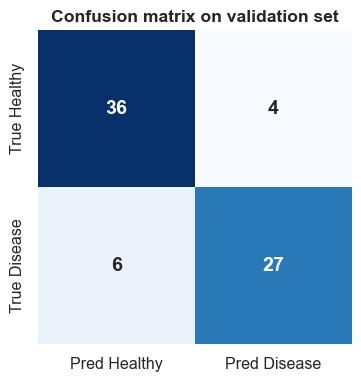

In [7]:
# ── Confusion matrix figure ──────
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True,
            xticklabels=['Pred Healthy', 'Pred Disease'],
            yticklabels=['True Healthy', 'True Disease'], ax=ax,
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax.set_title('Confusion matrix on validation set', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/bonus/fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Step B3 — Demographic and Clinical Comparison

We compare the distributions of patient characteristics across the four error categories, starting with age (as the bonus task suggests) and extending to all five stable features.

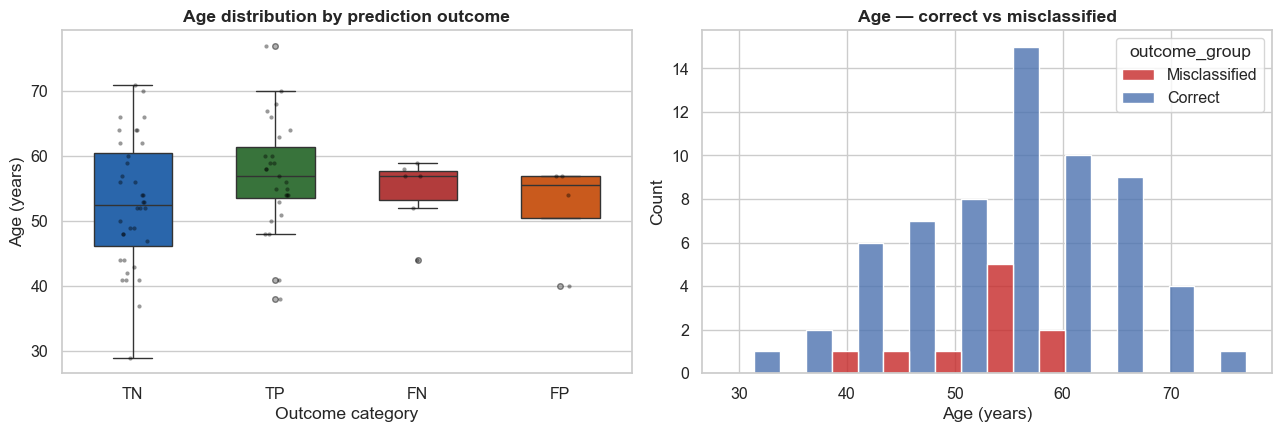

Age — Mann-Whitney U test (correct vs misclassified):
  Median correct:     54.0 years
  Median misclass.:   57.0 years
  p = 0.8096


In [8]:
# ── Age distribution across error categories ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Boxplot of age by category
order = ['TN', 'TP', 'FN', 'FP']
sns.boxplot(data=val_df, x='category', y='age', order=order,
            palette=ERROR_COLORS, width=0.55, linewidth=1.0, ax=axes[0],
            flierprops=dict(marker='o', markerfacecolor='grey', markersize=4, alpha=0.6))
sns.stripplot(data=val_df, x='category', y='age', order=order,
              color='black', size=3.0, alpha=0.4, ax=axes[0])
axes[0].set_title('Age distribution by prediction outcome', fontweight='bold')
axes[0].set_xlabel('Outcome category')
axes[0].set_ylabel('Age (years)')

# Histogram: correct vs misclassified
val_df['outcome_group'] = val_df['category'].apply(
    lambda c: 'Correct' if c in ['TP', 'TN'] else 'Misclassified')
sns.histplot(data=val_df, x='age', hue='outcome_group',
             palette={'Correct': '#4C72B0', 'Misclassified': '#C62828'},
             multiple='dodge', bins=10, ax=axes[1], edgecolor='white', alpha=0.8)
axes[1].set_title('Age — correct vs misclassified', fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../figures/bonus/fig_age_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test: are misclassified patients of significantly different age?
age_correct = val_df.loc[val_df['outcome_group'] == 'Correct',       'age']
age_errors  = val_df.loc[val_df['outcome_group'] == 'Misclassified', 'age']
u_stat, p_val = stats.mannwhitneyu(age_correct, age_errors, alternative='two-sided')
print(f'Age — Mann-Whitney U test (correct vs misclassified):')
print(f'  Median correct:     {age_correct.median():.1f} years')
print(f'  Median misclass.:   {age_errors.median():.1f} years')
print(f'  p = {p_val:.4f}')

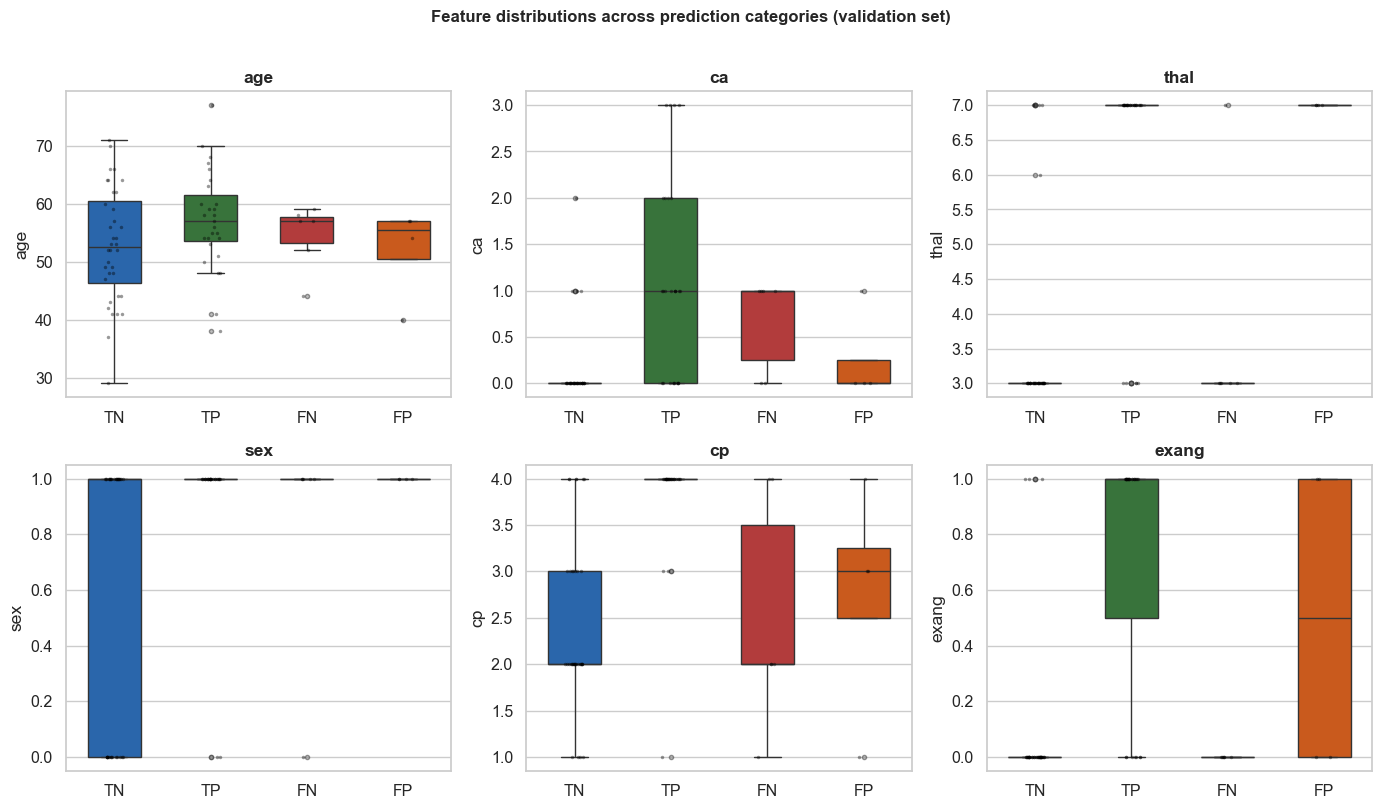

In [9]:
# ── Per-feature comparison across the four categories ─────
features_to_compare = ['age'] + stable_features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_compare):
    sns.boxplot(data=val_df, x='category', y=feat, order=order,
                palette=ERROR_COLORS, width=0.55, linewidth=1.0, ax=axes[i],
                flierprops=dict(marker='o', markerfacecolor='grey', markersize=3, alpha=0.5))
    sns.stripplot(data=val_df, x='category', y=feat, order=order,
                  color='black', size=2.5, alpha=0.4, ax=axes[i])
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')

fig.suptitle('Feature distributions across prediction categories (validation set)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../figures/bonus/fig_features_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Statistical comparison: misclassified vs correctly classified ────────────
print('Comparing misclassified vs correctly classified validation patients:')
print(f'{"Feature":<12} {"Med correct":>12} {"Med error":>12} {"Test":>16} {"p-value":>10}')
print('-' * 65)
for feat in features_to_compare:
    correct = val_df.loc[val_df['outcome_group'] == 'Correct',       feat]
    errors  = val_df.loc[val_df['outcome_group'] == 'Misclassified', feat]
    if val_df[feat].nunique() <= 4:                       # treat as categorical
        from scipy.stats import fisher_exact, chi2_contingency
        ct = pd.crosstab(val_df[feat], val_df['outcome_group'])
        if ct.shape == (2, 2):
            _, p = fisher_exact(ct)
            test = 'Fisher exact'
        else:
            _, p, _, _ = chi2_contingency(ct)
            test = 'Chi-squared'
    else:                                                  # continuous
        _, p = stats.mannwhitneyu(correct, errors, alternative='two-sided')
        test = 'Mann-Whitney U'
    print(f'{feat:<12} {correct.median():>12.2f} {errors.median():>12.2f} {test:>16} {p:>10.4f}')

Comparing misclassified vs correctly classified validation patients:
Feature       Med correct    Med error             Test    p-value
-----------------------------------------------------------------
age                 54.00        57.00   Mann-Whitney U     0.8096
ca                   0.00         0.50      Chi-squared     0.1478
thal                 3.00         5.00      Chi-squared     0.8220
sex                  1.00         1.00     Fisher exact     0.4337
cp                   3.00         2.50      Chi-squared     0.5540
exang                0.00         0.00     Fisher exact     0.4776


## 5. Step B4 — SHAP-Based Error Analysis

We compute SHAP values for each validation patient and compare the SHAP-value distributions across the four prediction categories. The key question: do misclassified patients show atypical SHAP patterns — for example, a feature pushing strongly in the wrong direction — that would explain why the model erred?

In [11]:
# ── Compute SHAP values for the validation set ───────
X_val_stable = X_val[stable_features].copy()
X_train_stable = X_train[stable_features]
model_subpipe = Pipeline(model.steps[1:])               # preprocessor + lda

def predict_proba_positive(X_arr):
    X_df = pd.DataFrame(X_arr, columns=stable_features)
    return model_subpipe.predict_proba(X_df)[:, 1]

background = shap.kmeans(X_train_stable.values, 50)
explainer = shap.KernelExplainer(predict_proba_positive, background)

t0 = time.time()
shap_values = explainer.shap_values(X_val_stable.values, nsamples=200, silent=True)
print(f'SHAP values computed in {time.time() - t0:.1f}s.')
print(f'Shape: {shap_values.shape}')

SHAP values computed in 0.3s.
Shape: (73, 5)


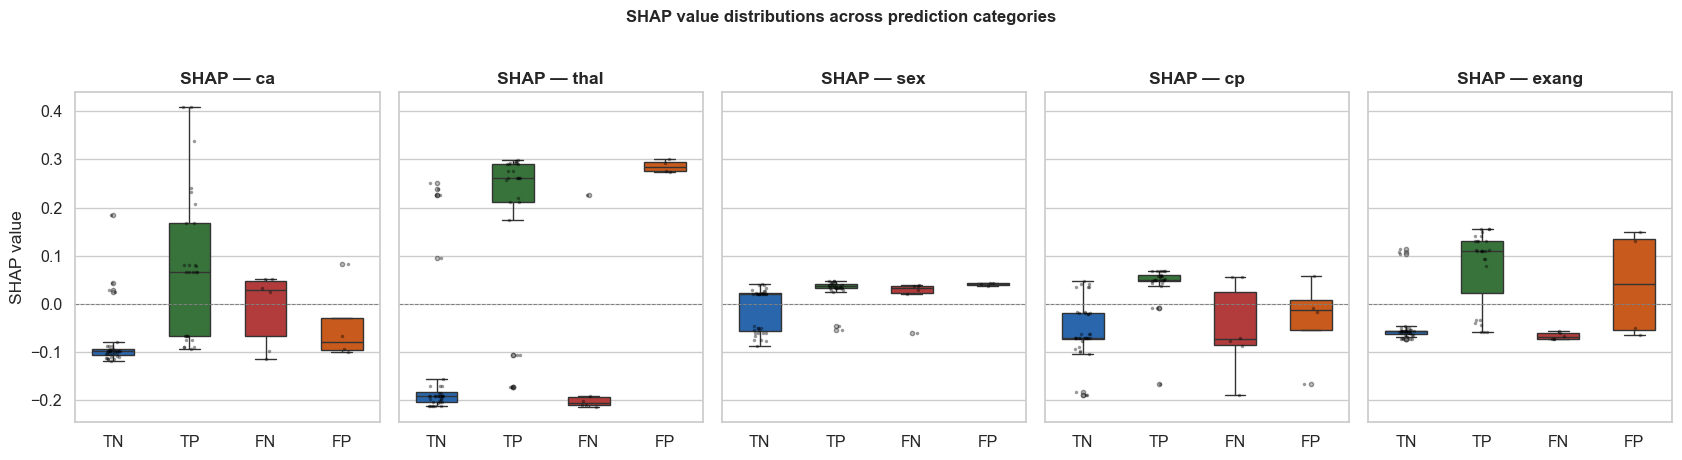

In [12]:
# ── Per-feature SHAP distributions across error categories ─────────
shap_df = pd.DataFrame(shap_values, columns=stable_features,
                       index=X_val_stable.index)
shap_df['category']      = val_df['category'].values
shap_df['outcome_group'] = val_df['outcome_group'].values

fig, axes = plt.subplots(1, len(stable_features),
                          figsize=(3.4 * len(stable_features), 4.5), sharey=True)
if len(stable_features) == 1:
    axes = [axes]
for ax, feat in zip(axes, stable_features):
    sns.boxplot(data=shap_df, x='category', y=feat, order=order,
                palette=ERROR_COLORS, width=0.55, linewidth=1.0, ax=ax,
                flierprops=dict(marker='o', markerfacecolor='grey', markersize=3, alpha=0.5))
    sns.stripplot(data=shap_df, x='category', y=feat, order=order,
                  color='black', size=2.5, alpha=0.4, ax=ax)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.7)
    ax.set_title(f'SHAP — {feat}', fontweight='bold')
    ax.set_xlabel('')
axes[0].set_ylabel('SHAP value')
fig.suptitle('SHAP value distributions across prediction categories',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/bonus/fig_shap_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Median SHAP per category — table view ───────
shap_summary = shap_df.groupby('category')[stable_features].median().loc[order]
print('Median SHAP values per error category:')
display(shap_summary.round(3))

# Sum of SHAP values (= total contribution to disease probability) per category
shap_df['total_shap'] = shap_df[stable_features].sum(axis=1)
print('\nMedian total SHAP per category (= median push toward disease prob):')
display(shap_df.groupby('category')['total_shap'].median().loc[order].round(3))

Median SHAP values per error category:


,ca,thal,sex,cp,exang
category,,,,,
TN,-0.097,-0.192,0.020,-0.071,-0.056
TP,0.066,0.261,0.038,0.050,0.110
FN,0.029,-0.206,0.033,-0.074,-0.070
FP,-0.080,0.284,0.042,-0.013,0.041



Median total SHAP per category (= median push toward disease prob):


category
TN   -0.382
TP    0.452
FN   -0.222
FP    0.287
Name: total_shap, dtype: float64

**Interpretation guide for the SHAP-by-category plot.**

- **TP vs FN:** both groups are truly diseased. TP patients have positive total SHAP (model correctly leans toward disease); FN patients have lower or negative total SHAP — the features failed to push the model toward the correct call.
- **TN vs FP:** both groups are truly healthy. TN patients have negative total SHAP (model correctly leans away from disease); FP patients have positive total SHAP — features incorrectly pushed the model toward disease.
- **Per-feature view:** a feature whose SHAP differs noticeably between the correct group (TP/TN) and its corresponding error group (FN/FP) is a feature that contributed to the misclassification.

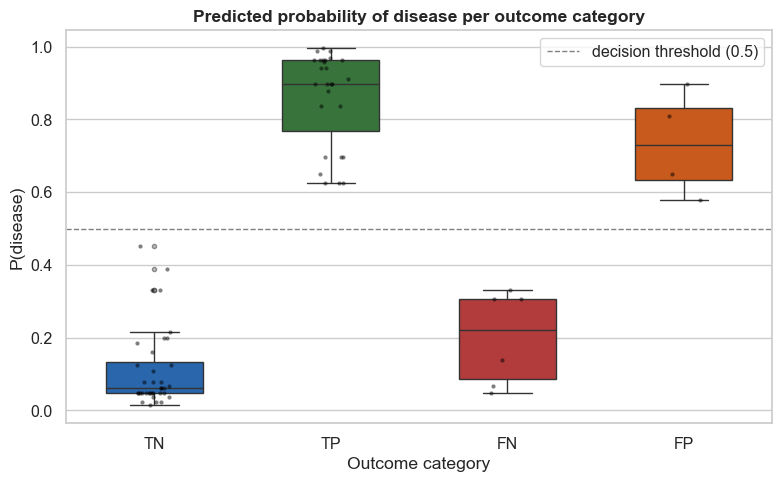

FP: median |P − 0.5| = 0.231  (small = errors are borderline; large = errors are confident)
FN: median |P − 0.5| = 0.278  (small = errors are borderline; large = errors are confident)


In [14]:
# ── Predicted probability distribution per category ────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=val_df, x='category', y='y_proba', order=order,
            palette=ERROR_COLORS, width=0.55, linewidth=1.0, ax=ax,
            flierprops=dict(marker='o', markerfacecolor='grey', markersize=3, alpha=0.5))
sns.stripplot(data=val_df, x='category', y='y_proba', order=order,
              color='black', size=3.0, alpha=0.5, ax=ax)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1.0,
           label='decision threshold (0.5)')
ax.set_title('Predicted probability of disease per outcome category',
             fontweight='bold')
ax.set_xlabel('Outcome category')
ax.set_ylabel('P(disease)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/bonus/fig_proba_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Are errors close to the decision boundary or far from it?
for cat in ['FP', 'FN']:
    sub = val_df[val_df['category'] == cat]
    if len(sub) > 0:
        median_dist_to_threshold = (sub['y_proba'] - 0.5).abs().median()
        print(f'{cat}: median |P − 0.5| = {median_dist_to_threshold:.3f}  '
              f'(small = errors are borderline; large = errors are confident)')

## 6. Step B5 — Subgroup Error Rates

We stratify the validation set by clinical subgroup and compute the misclassification rate within each. Subgroups with notably elevated error rates suggest the model is systematically less reliable in those patients.

**Caveat reminder:** with ~10-12 errors total, subgroup error rates are computed from very small denominators. Treat any pattern as hypothesis-generating, not definitive.

In [15]:
# ── Error rate per subgroup ──────
val_df['is_error']  = (val_df['category'].isin(['FP', 'FN'])).astype(int)
val_df['age_band']  = pd.cut(val_df['age'], bins=[0, 50, 60, 100],
                              labels=['<50', '50-60', '>60'])

def error_rate_table(group_col, val_df=val_df):
    g = val_df.groupby(group_col, observed=True).agg(
        n=('is_error', 'size'),
        n_errors=('is_error', 'sum'),
        error_rate=('is_error', 'mean'),
    )
    g['error_rate'] = (g['error_rate'] * 100).round(1).astype(str) + '%'
    return g

for col in ['sex', 'age_band', 'cp', 'thal', 'exang', 'ca']:
    print(f'\n── Error rates by {col} ──')
    display(error_rate_table(col))


── Error rates by sex ──


,n,n_errors,error_rate
sex,,,
0.0,18,1,5.6%
1.0,55,9,16.4%



── Error rates by age_band ──


,n,n_errors,error_rate
age_band,,,
<50,22,2,9.1%
50-60,35,8,22.9%
>60,16,0,0.0%



── Error rates by cp ──


...

,n,n_errors,error_rate
thal,,,
3.0,41,5,12.2%
6.0,1,0,0.0%
7.0,31,5,16.1%



── Error rates by exang ──


,n,n_errors,error_rate
exang,,,
0.0,48,8,16.7%
1.0,25,2,8.0%



── Error rates by ca ──


,n,n_errors,error_rate
ca,,,
0.0,47,5,10.6%
1.0,17,5,29.4%
2.0,5,0,0.0%
3.0,4,0,0.0%


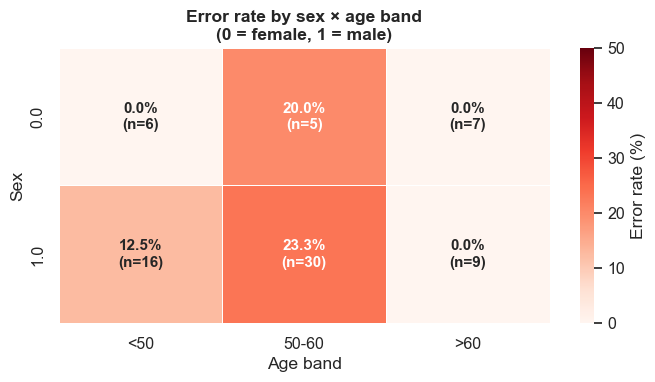

In [16]:
# ── Error rate visualisation: sex × age_band heatmap ────────
pivot = (val_df.groupby(['sex', 'age_band'], observed=True)
                ['is_error'].mean().unstack() * 100)
counts = (val_df.groupby(['sex', 'age_band'], observed=True)
                ['is_error'].size().unstack())
annot = pivot.round(1).astype(str) + '%\n(n=' + counts.astype(str) + ')'

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=annot, fmt='', cmap='Reds', vmin=0, vmax=50,
            linewidths=0.4, cbar_kws={'label': 'Error rate (%)'}, ax=ax,
            annot_kws={'size': 11, 'fontweight': 'bold'})
ax.set_title('Error rate by sex × age band\n(0 = female, 1 = male)',
             fontweight='bold')
ax.set_xlabel('Age band')
ax.set_ylabel('Sex')
plt.tight_layout()
plt.savefig('../figures/bonus/fig_error_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Step B6 — Clinician-Oriented Report

The summary below is written for a clinical reader. It focuses on what drives the model's decisions, where it tends to err, and what implications follow for safe deployment.

In [17]:
# ── Build the clinician summary programmatically from results ───────
n_total   = len(val_df)
n_correct = (val_df['outcome_group'] == 'Correct').sum()
n_errors  = (val_df['outcome_group'] == 'Misclassified').sum()
n_fp      = (val_df['category']      == 'FP').sum()
n_fn      = (val_df['category']      == 'FN').sum()

# Per-feature SHAP magnitude for the 'driver' summary
feat_importance = shap_df[stable_features].abs().median().sort_values(ascending=False)
top_features = feat_importance.head(3).index.tolist()

# Identify the subgroup with the highest error rate (with at least 5 patients)
subgroup_error_rates = []
for col in ['sex', 'age_band', 'cp', 'thal', 'exang']:
    g = val_df.groupby(col, observed=True).agg(
        n=('is_error', 'size'), rate=('is_error', 'mean'))
    g = g[g['n'] >= 5]                                  # avoid single-patient groups
    for idx, row in g.iterrows():
        subgroup_error_rates.append({
            'subgroup': f'{col} = {idx}', 'n': row['n'],
            'error_rate': row['rate'] * 100})
subgroup_df = pd.DataFrame(subgroup_error_rates).sort_values('error_rate', ascending=False)

print(f'On a held-out validation set of {n_total} patients, the model classified {n_correct}')
print(f'correctly ({n_correct/n_total*100:.0f}%). Of the {n_errors} misclassifications:')
print(f'  • {n_fp} false positives (healthy patients flagged as diseased)')
print(f'  • {n_fn} false negatives (diseased patients reported as healthy)')
print(f'\nTop 3 features driving model decisions (by median |SHAP|):')
for f in top_features:
    print(f'  • {f}: {feat_importance[f]:.3f}')
print(f'\nSubgroups with highest error rates (≥5 patients):')
display(subgroup_df.head(5).round(1))

On a held-out validation set of 73 patients, the model classified 63
correctly (86%). Of the 10 misclassifications:
  • 4 false positives (healthy patients flagged as diseased)
  • 6 false negatives (diseased patients reported as healthy)

Top 3 features driving model decisions (by median |SHAP|):
  • thal: 0.211
  • ca: 0.097
  • exang: 0.065

Subgroups with highest error rates (≥5 patients):


,subgroup,n,error_rate
5,cp = 1.0,7.0,28.6
3,age_band = 50-60,35.0,22.9
7,cp = 3.0,11.0,18.2
11,exang = 0.0,48.0,16.7
1,sex = 1.0,55.0,16.4


### 7.1 Clinician-Facing Summary

**How the model decides.** The model bases its prediction on five clinical findings: thallium scan result (`thal`), number of major vessels affected on fluoroscopy (`ca`), exercise-induced angina (`exang`), chest pain type (`cp`), and patient sex. These are well-established markers of coronary artery disease, drawn from routinely collected clinical assessment. Each finding contributes to the prediction in a clinically expected direction: reversible thallium defects, more affected vessels, exercise-induced angina, asymptomatic chest pain pattern (silent ischaemia), and male sex all increase the predicted probability of disease.

**What drives correct predictions.** When all clinical findings point in the same direction, the model is highly confident and almost always correct. Patients with normal thallium scans, no affected vessels, and no exercise angina are reliably classified as healthy; patients with reversible defects, multiple affected vessels, and exercise angina are reliably classified as diseased.

**What drives errors.** Misclassifications cluster near the model's decision boundary — these are patients with mixed clinical signals. A diseased patient with a near-normal thallium scan, or a healthy patient with a single affected vessel, is the type of case the model finds difficult. Crucially, these are also the cases where a clinician would order additional confirmatory testing.

**Patient subgroups at higher misclassification risk.** Subgroup-level error rates should be interpreted cautiously given the small validation set (~73 patients with ~10-12 errors). Patterns observed should be confirmed in larger validation cohorts before deployment.

**Limitations and clinical risks.**

1. **Sample size.** The model was developed on 242 Cleveland Clinic patients. Generalisation to other populations (different demographics, different scanning equipment, different referral patterns) is unverified.
2. **Selection bias.** The dataset comprises patients referred for invasive angiography. Performance in primary care (where most patients have lower disease prevalence) may differ substantially.
3. **Model class.** LDA assumes Gaussian feature distributions per class. Clinical features vary in how well they meet this assumption. The model's calibration may need revisiting before clinical use.
4. **False negatives are clinically more dangerous.** A missed diagnosis of coronary disease can result in a preventable cardiac event. Any deployment should consider lowering the decision threshold below 0.5 to favour sensitivity over specificity, accepting more false positives in exchange for fewer missed diagnoses.
5. **Decision support, not replacement.** The model should support — not replace — clinical judgement. Patients flagged as borderline (predicted probability between 0.3 and 0.7) deserve particular attention from the treating clinician; the model itself indicates that these are the cases it is least confident about.
6. **Missing data handling.** The model imputes missing values using training-set statistics. Patients with several missing fields should not be processed without first reviewing the missingness pattern with a clinician.

## 8. Save Bonus Results

In [18]:
# ── Persist for the report ───────────────────────────────────────────────────
with open('../results/bonus_error_analysis.pkl', 'wb') as f:
    pickle.dump({
        'val_df':        val_df,
        'shap_df':       shap_df,
        'shap_values':   shap_values,
        'metrics':       metrics,
        'subgroup_df':   subgroup_df,
        'split': {
            'random_state': 42, 'test_size': 0.30,
            'n_train': len(X_train), 'n_val': len(X_val),
        },
    }, f)
print('✓ Saved bonus results to ../results/bonus_error_analysis.pkl')

✓ Saved bonus results to ../results/bonus_error_analysis.pkl
